# 08 통합 Manifest — 멀티 파이프라인 결과 병합

**03~07 노트북**에서 생성한 개별 manifest JSON을 **프레임 단위로 병합**해 하나의 `unified_manifest.json`을 만듭니다.

| Part | 주제 |
|------|------|
| 1 | manifest 소스 탐색 · IPAD 프레임 인덱스 |
| 2 | 소스별 로드 · 정규화(normalize) · 스키마 검증 |
| 3 | 프레임 키 조인 · `merge_frame_records` · 통합 스코어 |
| 4 | unified_manifest export · 커버리지 대시보드 |
| 5 | Manifest Query API · CSV export |
| 6 | 다중 신호 타임라인 · 소스 공발생(co-occurrence) 분석 |
| 7 | 알람 후보 썸네일 모자이크 · 최종 리포트 |

### 통합 대상 manifest

| 노트북 | 파일 | 주요 신호 |
|--------|------|-----------|
| 03 샘플링 | `output_sampling/sampling_manifest.json` | swin/detr 선별 프레임 인덱스 |
| 05 VLM 요약 | `output_vlm_summary/summary_manifest.json` | vlm_frames, text_summary |
| 04 이상 탐지 | `output_anomaly_scene/anomaly_manifest.json` | anomaly_scenes, top_frame_indices |
| 06 OCR | `output_ocr_kr/ocr_manifest_ipad.json` | full_text, detections |
| 07 키포인트 | `output_keypoint/keypoint_manifest.json` | displacement, motion_z |

```
개별 manifest (03~07)
        ↓ normalize + frame key
   프레임별 signal 레코드
        ↓ join
unified_manifest.json + figures/
```

> 선행 실행: 통합하려는 노트북(03~07)을 먼저 실행해 각 `output_*` 폴더에 manifest를 생성하세요. 없어도 **있는 manifest만** 병합합니다.


### 본 실습에서 다루는 기술

| 기법 | 한 줄 설명 | 코드에서의 역할 |
|------|-----------|----------------|
| **Manifest Registry** | 소스 경로·스키마 정의 | `MANIFEST_SOURCES` |
| **Frame Key** | 경로/인덱스 통일 키 | `normalize_frame_key`, `frame_key_from_index` |
| **Signal Extractor** | 소스별 필드 파싱 | `extract_*_signals` |
| **Schema Validator** | 소스별 필수 키 검사 | `validate_manifest_schema` |
| **Join Engine** | 프레임 단위 병합 · OCR 우선순위 | `merge_frame_records` |
| **Agreement Score** | 파이프라인 합의도 | `compute_signal_agreement` |
| **Unified Export** | JSON + CSV | `export_unified_manifest`, `export_frames_csv` |
| **Manifest Query** | 조건 검색 API | `ManifestQuery` |
| **Timeline Dashboard** | 스코어·신호 시계열 | `plot_unified_timeline`, `plot_source_overlap` |
| **Coverage Dashboard** | 소스별 커버리지 | `plot_manifest_coverage` |

핵심: 영상 AI 파이프라인은 **모듈별 JSON**을 만들고, 실무 연동은 **통합 manifest** 한 장으로 합니다.


### 학습 가이드 — 통합 Manifest란?

**한 줄 요약**  
여러 AI 모듈(샘플링, 이상탐지, OCR, 키포인트 등)이 각자 만든 JSON을 **프레임 단위로 한데 모아**, 하나의 `unified_manifest.json`으로 정리하는 실습입니다.

**왜 통합이 필요한가?**  
실무 영상 AI는 보통 **모듈별로 따로** 돌아갑니다.

```
03 샘플링  →  "중요한 프레임은 8, 38, 179번"
04 이상탐지 →  "0~12번 구간이 수상함"
06 OCR     →  "42번 프레임에 'WARNING' 텍스트"
07 키포인트 →  "128번에서 motion_z 급증"
```

각각 다른 파일·다른 형식입니다. 운영 대시보드나 알람 시스템은 **한 타임라인**에서 이 정보를 같이 봐야 하므로, 중간에 **통합 manifest 레이어**가 필요합니다.

**전체 파이프라인 흐름**

```
[03~07 개별 manifest JSON]
        ↓  로드 · 스키마 검증
[frame_key 기준 조인]
        ↓  신호 추출 · 병합 · 점수화
[unified_manifest.json + CSV + 차트]
        ↓  Query API · 상관 분석 · 썸네일
[운영·리포트·육안 검증]
```

**실습 순서**  
1. 위에서 아래로 셀을 **순서대로** 실행합니다.  
2. 03~07 중 일부만 실행했다면, 있는 manifest만 병합됩니다 (`[MISS]`는 정상).  
3. 각 Part 제목 아래 **「기술 설명」** 블록을 먼저 읽고 코드를 실행하면 이해가 쉽습니다.

**선행 지식 (없어도 따라 할 수 있음)**  
- JSON 기본 구조 (`{ "key": value }`)  
- 프레임 = 영상의 한 장 정지 화면  
- `frame_index` = 0부터 시작하는 프레임 번호

In [1]:
# ── 패키지 설치 (최초 1회, 주석 해제 후 실행) ──
# requirements.txt: opencv, numpy, matplotlib, scipy 등 03~07과 동일 의존성
# !pip install -q -r requirements.txt


### 기술 설명 — 환경 설정

**이 코드 블록의 역할**  
노트북 전반에서 쓰는 **경로·상수·데이터 클래스**를 한곳에 정의합니다. 이 셀을 먼저 실행해야 이후 모든 Part가 같은 설정을 공유합니다.

**초보자가 알아두면 좋은 개념**

| 설정 | 의미 |
|------|------|
| `MANIFEST_SOURCES` | 병합할 개별 JSON 파일 경로 목록 (레지스트리) |
| `OUTPUT_DIR` / `FIG_DIR` | 통합 결과 JSON·CSV·그림 저장 위치 |
| `SCORE_WEIGHTS` | unified_score 계산 시 신호별 가중치 |
| `ALERT_SCORE_THRESHOLD` | 알람 후보로 볼 최소 점수 |
| `MANIFEST_SCHEMA` | 소스별 JSON에 반드시 있어야 할 키 집합 |
| `LoadedManifest` | 로드된 manifest 한 건 (이름, 경로, 데이터) |
| `FrameRecord` | 프레임 하나의 통합 레코드 (신호·소스 목록) |

**비유로 이해하기**  
- `MANIFEST_SOURCES` = 여러 부서(03~07)에서 올라온 **보고서 목록**  
- `FrameRecord` = 보고서들을 **프레임 단위로 합친 한 줄**  
- `SCORE_WEIGHTS` = 최종 위험도를 정할 때 항목별 **배점표**

**한글 폰트 설정**  
matplotlib 차트 제목·축 라벨에 한글이 깨지지 않도록 OS별 폰트를 자동 선택합니다. Windows는 맑은 고딕, Colab은 나눔 폰트를 설치합니다.

> 경로·가중치는 현장 환경에 맞게 수정할 수 있습니다. 코드 본문의 주석을 참고하세요.

In [2]:
from __future__ import annotations

# =============================================================================
# 환경 설정 — import, manifest 소스 경로, 출력 경로, 한글 폰트
# =============================================================================

# 표준 라이브러리: JSON I/O, OS/플랫폼 감지, ZIP 압축 해제, 타입 힌트용 dataclass
import json
import os
import platform
import subprocess
import zipfile
from dataclasses import dataclass, field
from datetime import datetime, timezone
from pathlib import Path

# 시각화·수치 연산 (히트맵, 타임라인, 스코어 계산)
import matplotlib.pyplot as plt
import numpy as np

# ── 개별 manifest 입력 경로 (03~07 산출물) ───────────────────────────────────
# key: 내부 식별자 / value: 각 노트북이 생성한 JSON 경로
# 존재하지 않는 파일은 Part 1에서 [MISS]로 표시되고 병합에서 제외됨
MANIFEST_SOURCES = {
    "sampling": Path("output_sampling/sampling_manifest.json"),
    "vlm_summary": Path("output_vlm_summary/summary_manifest.json"),
    "anomaly_scene": Path("output_anomaly_scene/anomaly_manifest.json"),
    "ocr_ipad": Path("output_ocr_kr/ocr_manifest_ipad.json"),
    "ocr_hub": Path("output_ocr_kr/ocr_manifest.json"),
    "keypoint": Path("output_keypoint/keypoint_manifest.json"),
}

# ── 통합 manifest 출력 ───────────────────────────────────────────────────────
# OUTPUT_DIR: JSON·CSV 등 텍스트 산출물
# FIG_DIR: matplotlib/OpenCV로 생성한 그림 파일
OUTPUT_DIR = Path("output_unified")
FIG_DIR = OUTPUT_DIR / "figures"
UNIFIED_MANIFEST_PATH = OUTPUT_DIR / "unified_manifest.json"
COVERAGE_REPORT_PATH = OUTPUT_DIR / "manifest_coverage.json"

# IPAD 프레임 (조인 기준 타임라인)
# 여러 파이프라인이 서로 다른 경로 표기를 쓰므로, IPAD testing 프레임 순서를 공통 시계열로 사용
IPAD_ZIP_NAMES = ("IPAD_sample.zip", "IPAD_Sample.zip")
IPAD_SEARCH_PATHS = [Path("IPAD_Sample"), Path("IPAD_sample")]
FRAME_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
FPS_ASSUMED = 30.0  # frame_index → time_sec 변환 시 사용 (실제 FPS 모를 때 가정값)

# ── 통합 스코어 가중치 (현장 도메인에 맞게 조정) ───────────────────────────────
# 각 신호가 unified_score에 기여하는 비중. 합이 1을 넘을 수 있으나 최종 score는 min(., 1.0)으로 캡
SCORE_WEIGHTS = {
    "anomaly_candidate": 0.45,
    "anomaly_top": 0.10,
    "vlm_keyframe": 0.20,
    "sampling": 0.10,
    "motion_z_high": 0.20,
    "ocr_detected": 0.05,
}
MOTION_Z_THRESHOLD = 2.0       # 키포인트 displacement z-score가 이 값 이상이면 '움직임 급증'으로 간주
ALERT_SCORE_THRESHOLD = 0.55   # 이 점수 이상 프레임을 알람 후보로 선정
ALERT_TOP_K = 8                # threshold 미달이어도 상위 K개는 후보에 포함

# manifest 소스별 최소 스키마 (필수 키)
# 로드 직후 validate_manifest_schema()로 누락·타입 오류를 경고
MANIFEST_SCHEMA = {
    "sampling": {"presets"},
    "vlm_summary": {"vlm_frames"},
    "anomaly_scene": {"top_frame_indices"},
    "ocr_ipad": {"results"},
    "ocr_hub": {"results"},
    "keypoint": {"frames"},
}

for d in (OUTPUT_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)  # 없으면 생성, 있으면 그대로 사용


def is_running_in_colab() -> bool:
    """Google Colab 환경 여부. Colab이면 한글 폰트 apt 설치 분기."""
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def setup_matplotlib_korean() -> None:
    """OS별 한글 폰트 후보를 탐색해 matplotlib 기본 폰트로 설정."""
    from matplotlib import font_manager
    if is_running_in_colab():
        # Colab: 나눔 폰트 패키지 설치 후 폰트 캐시 갱신
        subprocess.run(
            ["apt-get", "-qq", "-y", "install", "fonts-nanum"],
            check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
        )
        font_manager._load_fontmanager(try_read_cache=False)
    # 플랫폼별 한글 폰트 후보 목록 (설치된 것 중 첫 번째 사용)
    if platform.system() == "Windows":
        candidates = ["Malgun Gothic", "NanumGothic", "Gulim"]
        fallback = Path(os.environ.get("WINDIR", r"C:\Windows")) / "Fonts" / "malgun.ttf"
    elif platform.system() == "Darwin":
        candidates = ["AppleGothic", "Apple SD Gothic Neo"]
        fallback = None
    else:
        candidates = ["NanumGothic", "NanumBarunGothic"]
        fallback = Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
    available = {f.name for f in font_manager.fontManager.ttflist}
    chosen = next((n for n in candidates if n in available), None)
    if chosen:
        plt.rcParams["font.family"] = chosen
    elif fallback and fallback.exists():
        # 시스템에 등록되지 않은 경우 ttf 파일을 직접 등록
        font_manager.fontManager.addfont(str(fallback))
        plt.rcParams["font.family"] = font_manager.FontProperties(fname=str(fallback)).get_name()
    plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지


@dataclass
class LoadedManifest:
    """디스크에서 성공적으로 읽어온 개별 manifest 한 건."""
    name: str      # MANIFEST_SOURCES 키 (예: sampling, keypoint)
    path: Path     # 실제 파일 경로
    data: dict     # 파싱된 JSON 본문
    status: str = "ok"


@dataclass
class FrameRecord:
    """프레임 하나에 대한 통합 작업 단위. frame_key로 여러 소스 신호를 누적."""
    frame_index: int | None = None   # IPAD 타임라인 상 인덱스 (0-based)
    image_path: str | None = None    # 원본 이미지 절대/상대 경로
    frame_key: str = ""              # 조인용 정규화 키 (예: frames/01/000.jpg)
    signals: dict = field(default_factory=dict)  # 파이프라인별 추출 신호
    sources: list[str] = field(default_factory=list)  # 기여한 manifest 이름 목록


setup_matplotlib_korean()
print("환경 설정 완료")


환경 설정 완료


### 기술 설명 — IPAD 프레임 로드 · manifest I/O · frame key 유틸

**이 코드 블록의 역할**  
Part 1~7에서 반복 호출하는 **공통 도구 함수**를 모아 둔 셀입니다. IPAD 데이터 찾기, JSON 읽기, 프레임 조인 키 만들기, 스키마 검증이 여기서 정의됩니다.

**초보자가 알아두면 좋은 개념**

| 함수 | 하는 일 |
|------|---------|
| `_search_roots()` | 노트북·작업 폴더 등 IPAD zip을 찾을 루트 경로 목록 |
| `ensure_ipad_sample()` | `IPAD_Sample` 폴더가 없으면 zip 자동 압축 해제 |
| `load_ipad_testing_frames()` | testing 클립 프레임 경로를 **이름 순 정렬**해 반환 |
| `load_json_manifest()` | JSON 파일 읽기. 없거나 깨지면 `None` |
| `normalize_frame_key()` | 서로 다른 경로 표기를 **하나의 키**로 통일 |
| `frame_key_from_index()` | 정수 인덱스 → frame_key |
| `validate_manifest_schema()` | 필수 키·타입 이상을 경고 문자열 목록으로 반환 |

**frame_key가 왜 중요한가? (핵심)**  
데이터베이스에서 **기본 키(primary key)** 가 있어야 행을 합칠 수 있듯이, manifest 통합에도 프레임마다 **고유 식별자**가 필요합니다.

```
C:\...\IPAD_Sample\R01\testing\frames\01\042.jpg
                ↓ normalize_frame_key
         frames/01/042.jpg   ← 모든 소스가 이 키로 조인
```

**스키마 검증은 왜 하나?**  
파일이 존재해도 내용이 비어 있거나 키 이름이 바뀌면 조용히 잘못된 병합이 일어날 수 있습니다. 사전에 `missing key: presets` 같은 경고를 띄워 **조기 발견**합니다.

In [3]:
# =============================================================================
# IPAD 프레임 로드 · manifest I/O · frame key 유틸
# =============================================================================

def _search_roots() -> list[Path]:
    """IPAD zip·폴더를 찾을 때 탐색할 루트 경로 목록 (cwd + 노트북 위치)."""
    roots: list[Path] = [Path.cwd().resolve()]
    try:
        from IPython import get_ipython
        ip = get_ipython()
        # VS Code / Cursor 노트북 실행 시 노트북 파일이 있는 디렉터리를 우선 탐색
        nb_file = ip.user_ns.get("__vsc_ipynb_file__") if ip else None
        if nb_file:
            nb_dir = Path(nb_file).resolve().parent
            if nb_dir not in roots:
                roots.insert(0, nb_dir)
    except Exception:
        pass
    return roots


def find_ipad_zip() -> Path | None:
    """프로젝트 루트 근처에서 IPAD 샘플 zip 파일을 찾음."""
    for root in _search_roots():
        for name in IPAD_ZIP_NAMES:
            p = root / name
            if p.is_file():
                return p
    return None


def ensure_ipad_sample() -> Path | None:
    """IPAD_Sample 폴더가 없으면 zip을 자동 압축 해제해 반환."""
    # 이미 압축 해제된 폴더가 있고 이미지가 있으면 바로 사용
    for root in _search_roots():
        for rel in IPAD_SEARCH_PATHS:
            base = root / rel
            if base.is_dir() and any(p.suffix.lower() in FRAME_EXTS for p in base.rglob("*") if p.is_file()):
                return base
    zpath = find_ipad_zip()
    if zpath is None:
        return None
    extract_to = zpath.parent
    print(f"[IPAD] {zpath.name} 압축 해제 -> {extract_to.resolve()}")
    with zipfile.ZipFile(zpath, "r") as zf:
        zf.extractall(extract_to)
    for rel in IPAD_SEARCH_PATHS:
        if (extract_to / rel).is_dir():
            return extract_to / rel
    return None


def load_ipad_testing_frames() -> list[Path]:
    # testing 클립 프레임을 정렬해 반환 (통합 타임라인 기준).
    root = ensure_ipad_sample()
    if root is None:
        return []
    # testing → training 순으로 frames/ 하위 첫 클립 디렉터리의 이미지 목록 사용
    for split in ("testing", "training"):
        for frames_root in root.rglob("frames"):
            if split not in str(frames_root):
                continue
            for clip_dir in sorted(frames_root.iterdir()):
                if not clip_dir.is_dir():
                    continue
                files = sorted(
                    [p for p in clip_dir.iterdir() if p.suffix.lower() in FRAME_EXTS],
                    key=lambda p: p.name,  # 000.jpg, 001.jpg, ... 순서 보장
                )
                if files:
                    return files
    # 표준 구조가 없으면 루트 이하 모든 이미지를 파일명 순으로 반환
    return sorted(p for p in root.rglob("*") if p.suffix.lower() in FRAME_EXTS)


def load_json_manifest(path: Path) -> dict | None:
    """manifest JSON을 읽어 dict로 반환. 없거나 파싱 실패 시 None."""
    if not path.is_file():
        return None
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except json.JSONDecodeError as exc:
        print(f"[WARN] JSON 파싱 실패: {path} ({exc})")
        return None


def normalize_frame_key(path_or_name: str) -> str:
    # 프레임 조인 키: 파일명(000.jpg) + clip 경로 tail. frames/.../파일명 형태로 통일.
    p = Path(path_or_name)
    parts = [x.lower() for x in p.parts]  # 대소문자·역슬래시 차이 제거
    if "frames" in parts:
        i = parts.index("frames")
        tail = parts[i:]
        # frames/클립ID/파일명 최대 3단계만 사용해 경로 접두사 차이 흡수
        return "/".join(tail[-3:]) if len(tail) >= 3 else "/".join(tail)
    return p.name.lower()  # frames 경로가 없으면 파일명만으로 조인


def frame_key_from_index(ipad_frames: list[Path], idx: int) -> str | None:
    """정수 frame_index → normalize_frame_key. 인덱스 범위 밖이면 None."""
    if 0 <= idx < len(ipad_frames):
        return normalize_frame_key(str(ipad_frames[idx]))
    return None


def index_from_frame_key(ipad_frames: list[Path], key: str) -> int | None:
    """normalize_frame_key → frame_index 역조회용 룩업 테이블."""
    lookup = {normalize_frame_key(str(p)): i for i, p in enumerate(ipad_frames)}
    return lookup.get(key)


def sec_from_index(idx: int, fps: float = FPS_ASSUMED) -> float:
    """프레임 번호를 초 단위 시간으로 변환 (소수 셋째 자리 반올림)."""
    return round(idx / fps, 3)


def validate_manifest_schema(name: str, data: dict) -> list[str]:
    """소스별 필수 키 누락·타입 이상을 경고 목록으로 반환."""
    warnings: list[str] = []
    required = MANIFEST_SCHEMA.get(name, set())
    for key in required:
        if key not in data:
            warnings.append(f"missing key: {key}")
    # 소스별 추가 타입·길이 검증
    if name == "sampling" and "presets" in data and not isinstance(data["presets"], dict):
        warnings.append("presets must be dict")
    if name in ("ocr_ipad", "ocr_hub") and "results" in data and not isinstance(data["results"], list):
        warnings.append("results must be list")
    if name == "keypoint" and "frames" in data:
        n = len(data["frames"])
        z = len(data.get("displacement_zscore", []))
        # z-score 시계열은 보통 frames-1 길이 (프레임 간 변위 기준)
        if z and abs(z - max(n - 1, 0)) > 2:
            warnings.append(f"displacement_zscore length mismatch (frames={n}, z={z})")
    return warnings


def summarize_schema_validation(loaded: list[LoadedManifest]) -> dict[str, list[str]]:
    """로드된 manifest 전체에 대해 스키마 경고만 모아 coverage 리포트용 dict 생성."""
    report: dict[str, list[str]] = {}
    for m in loaded:
        issues = validate_manifest_schema(m.name, m.data)
        if issues:
            report[m.name] = issues
    return report


## Part 1 — manifest 소스 탐색 · IPAD 타임라인

개별 manifest 파일 존재 여부를 확인하고, IPAD testing 프레임 목록을 **공통 타임라인**으로 준비합니다.


### 기술 설명 — manifest 소스 탐색 · IPAD 타임라인

**이 단계에서 하는 일**  
통합 작업을 시작하기 전에 **재료가 준비됐는지** 확인합니다. 03~07 노트북이 만든 JSON 파일이 있는지 스캔하고, 모든 파이프라인이 공유할 **IPAD testing 프레임 목록**을 불러옵니다.

**초보자가 알아두면 좋은 개념**

| 용어 | 쉬운 설명 |
|------|-----------|
| **manifest** | AI 분석 결과를 담은 JSON 파일. 영상 전체가 아니라 **메타데이터·인덱스·점수** 위주 |
| **coverage (커버리지)** | 어떤 소스 파일이 있고 없는지 기록한 **준비 상태 리포트** |
| **타임라인** | 프레임을 시간 순서대로 나열한 기준축. 여기서는 IPAD testing 클립 사용 |
| **스키마 검증** | JSON 안에 **필수 키**가 있는지, 타입이 맞는지 사전 점검 |

**실행 시 출력 읽는 법**  
- `[ OK ] sampling -> ...` : 파일 존재 + JSON 파싱 성공 → 병합에 **포함**  
- `[MISS] vlm_summary -> ...` : 파일 없음 → **건너뜀** (다른 소스만으로 진행)  
- `IPAD testing 프레임: 230장` : 조인 기준이 되는 프레임 수  
- `[Schema] 경고` : 파일은 있지만 구조가 예상과 다름 → 결과 신뢰도 주의

**왜 IPAD 프레임이 필요한가?**  
일부 manifest는 `frame_index=42`처럼 **번호만** 주고, 다른 manifest는 `C:\...\042.jpg`처럼 **경로만** 줍니다. IPAD 프레임 목록이 있어야 번호와 경로를 **같은 프레임**으로 연결할 수 있습니다.

**생성 파일**  
- `output_unified/manifest_coverage.json` — 스캔 시각, found/missing 목록, 스키마 경고

In [4]:
# ── Part 1: manifest 소스 스캔 · IPAD 프레임 ──

loaded: list[LoadedManifest] = []   # 성공적으로 읽은 manifest 목록
missing: list[str] = []             # 파일 없음·파싱 실패한 소스 이름

# MANIFEST_SOURCES에 등록된 모든 경로를 순회하며 로드 시도
for name, path in MANIFEST_SOURCES.items():
    data = load_json_manifest(path)
    if data is None:
        missing.append(name)
        print(f"[MISS] {name:14s} -> {path}")
    else:
        loaded.append(LoadedManifest(name=name, path=path, data=data))
        print(f"[ OK ] {name:14s} -> {path}")

# 통합 조인의 기준이 되는 IPAD testing 프레임 시계열 로드
ipad_frames = load_ipad_testing_frames()
print(f"\nIPAD testing 프레임: {len(ipad_frames)}장")
if ipad_frames:
    print(f"  예: {ipad_frames[0].name} ... {ipad_frames[-1].name}")

# 커버리지 리포트: 어떤 소스가 있었는지, 스키마 경고가 있는지 기록
coverage = {
    "scanned_at": datetime.now(timezone.utc).isoformat(),
    "sources_found": [m.name for m in loaded],
    "sources_missing": missing,
    "ipad_frame_count": len(ipad_frames),
    "schema_warnings": summarize_schema_validation(loaded),
}
COVERAGE_REPORT_PATH.write_text(json.dumps(coverage, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"\n커버리지 리포트: {COVERAGE_REPORT_PATH}")

schema_issues = coverage["schema_warnings"]
if schema_issues:
    print("\n[Schema] 경고:")
    for src, issues in schema_issues.items():
        print(f"  {src}: {', '.join(issues)}")
else:
    print("\n[Schema] 모든 로드된 manifest 스키마 OK")


[ OK ] sampling       -> output_sampling\sampling_manifest.json
[ OK ] vlm_summary    -> output_vlm_summary\summary_manifest.json
[ OK ] anomaly_scene  -> output_anomaly_scene\anomaly_manifest.json
[ OK ] ocr_ipad       -> output_ocr_kr\ocr_manifest_ipad.json
[ OK ] ocr_hub        -> output_ocr_kr\ocr_manifest.json
[ OK ] keypoint       -> output_keypoint\keypoint_manifest.json

IPAD testing 프레임: 230장
  예: 000.jpg ... 229.jpg

커버리지 리포트: output_unified\manifest_coverage.json

[Schema] 모든 로드된 manifest 스키마 OK


## Part 2 — 소스별 신호 추출(normalize)

각 manifest에서 **프레임 단위 신호**만 뽑아 공통 스키마로 변환합니다.


### 기술 설명 — 소스별 신호 추출(normalize)

**이 단계에서 하는 일**  
03~07 노트북마다 JSON **형식이 제각각**입니다. 이 섹션은 각 manifest에서 필요한 값만 꺼내 **공통 구조(`FrameRecord`)**로 바꿉니다. 이 과정을 **정규화(normalize)** 또는 **신호 추출(signal extraction)** 이라고 부릅니다.

**초보자가 알아두면 좋은 개념**

| 용어 | 쉬운 설명 |
|------|-----------|
| **신호(signal)** | 프레임 하나에 붙는 분석 결과 (예: `anomaly_candidate=True`, `motion_z=2.3`) |
| **frame_store** | `frame_key` → `FrameRecord` 딕셔너리. 모든 소스가 여기에 **누적**됨 |
| **extractor** | manifest 종류별 파싱 함수 (`extract_sampling_signals` 등) |
| **_clip_meta** | 특정 프레임이 아닌 **클립 전체** 정보 (VLM 요약문, anomaly 장면 목록) |

**소스별로 무엇을 추출하나?**

| 소스 | 프레임 신호 | 클립 메타 |
|------|------------|-----------|
| sampling | `sampling_swin`, `sampling_detr` | — |
| vlm_summary | `vlm_keyframe` | text_summary, segments |
| anomaly_scene | `anomaly_candidate`, `anomaly_top` | anomaly_scenes, text_report |
| ocr_* | `ocr_full_text`, `ocr_detection_count` | — |
| keypoint | `displacement`, `motion_z` | motion_spike_frames |

**frame_key로 조인하는 이유**  
- sampling·anomaly는 **frame_index(정수)** 만 제공  
- OCR·keypoint는 **image_path(문자열)** 제공  
- `normalize_frame_key()`로 둘 다 `frames/01/000.jpg` 형태로 맞춰 **같은 프레임끼리 합침**

**빈 프레임도 채우는 이유**  
IPAD 타임라인의 모든 프레임에 `frame_index`, `time_sec`를 넣어 두면, 신호가 없는 구간도 타임라인 차트에서 **연속된 시계열**로 표현할 수 있습니다.

In [5]:
# ── Part 2: 소스별 signal extractor ──

def _ensure_record(store: dict[str, FrameRecord], key: str) -> FrameRecord:
    """frame_key에 해당하는 FrameRecord가 없으면 생성 후 반환 (조인 해시맵 패턴)."""
    if key not in store:
        store[key] = FrameRecord(frame_key=key)
    return store[key]


def extract_sampling_signals(data: dict, store: dict[str, FrameRecord], ipad_frames: list[Path]) -> None:
    """03 샘플링 manifest: swin/detr 등 preset별 선별 프레임 인덱스를 불리언 신호로 기록."""
    presets = data.get("presets", {})
    for preset_name, indices in presets.items():
        for idx in indices:
            key = frame_key_from_index(ipad_frames, int(idx))
            if key is None:
                continue
            rec = _ensure_record(store, key)
            rec.frame_index = int(idx)
            rec.signals[f"sampling_{preset_name}"] = True  # 예: sampling_swin, sampling_detr
            rec.sources.append("sampling")


def extract_vlm_signals(data: dict, store: dict[str, FrameRecord], ipad_frames: list[Path]) -> None:
    """05 VLM manifest: 키프레임 인덱스 + 클립 전체 텍스트 요약·세그먼트."""
    for idx in data.get("vlm_frames", []):
        key = frame_key_from_index(ipad_frames, int(idx))
        if key is None:
            continue
        rec = _ensure_record(store, key)
        rec.frame_index = int(idx)
        rec.signals["vlm_keyframe"] = True
        rec.sources.append("vlm_summary")
    # 클립 전체 메타는 clip-level로 store["_clip_meta"]에 보관
    store.setdefault("_clip_meta", FrameRecord(frame_key="_clip_meta"))
    store["_clip_meta"].signals["vlm_text_summary"] = data.get("text_summary")
    store["_clip_meta"].signals["vlm_query"] = data.get("query")
    store["_clip_meta"].signals["vlm_segments"] = data.get("segments")
    store["_clip_meta"].sources.append("vlm_summary")


def extract_anomaly_signals(data: dict, store: dict[str, FrameRecord], ipad_frames: list[Path]) -> None:
    """04 이상 탐지 manifest: top_frame_indices·anomaly_frames를 프레임별 플래그로 변환."""
    top_idxs = set(data.get("top_frame_indices", []))
    anomaly_idxs = set(data.get("anomaly_frames", []))
    for idx in top_idxs | anomaly_idxs:
        key = frame_key_from_index(ipad_frames, int(idx))
        if key is None:
            continue
        rec = _ensure_record(store, key)
        rec.frame_index = int(idx)
        rec.signals["anomaly_candidate"] = idx in anomaly_idxs
        rec.signals["anomaly_top"] = idx in top_idxs
        rec.sources.append("anomaly_scene")
    store.setdefault("_clip_meta", FrameRecord(frame_key="_clip_meta"))
    store["_clip_meta"].signals["anomaly_scenes"] = data.get("anomaly_scenes", [])
    store["_clip_meta"].signals["anomaly_report"] = data.get("text_report")
    store["_clip_meta"].sources.append("anomaly_scene")


def extract_ocr_signals(data: dict, store: dict[str, FrameRecord], source_name: str) -> None:
    """06 OCR manifest: image_path 기준 조인, full_text·detection 수 기록."""
    for item in data.get("results", []):
        path = item.get("image_path", "")
        key = normalize_frame_key(path)
        rec = _ensure_record(store, key)
        rec.image_path = path
        rec.signals["ocr_full_text"] = item.get("full_text", "")
        rec.signals["ocr_detection_count"] = len(item.get("detections", []))
        rec.signals["ocr_source"] = source_name  # ocr_ipad / ocr_hub 구분
        rec.sources.append(source_name)


def extract_keypoint_signals(data: dict, store: dict[str, FrameRecord]) -> None:
    """07 키포인트 manifest: 프레임별 displacement·motion_z + 클립 통계."""
    z_series = data.get("displacement_zscore", [])
    for i, fr in enumerate(data.get("frames", [])):
        path = fr.get("image_path", "")
        key = normalize_frame_key(path)
        rec = _ensure_record(store, key)
        rec.image_path = path
        rec.signals["keypoint_method"] = fr.get("method")
        rec.signals["keypoint_count"] = fr.get("num_feature_points")
        rec.signals["displacement"] = fr.get("displacement")
        rec.signals["motion_z"] = fr.get("motion_z")
        # 프레임 레코드에 motion_z가 없으면 z_series[i-1]로 보완
        if i > 0 and i - 1 < len(z_series):
            rec.signals.setdefault("motion_z", z_series[i - 1])
        rec.sources.append("keypoint")
    store.setdefault("_clip_meta", FrameRecord(frame_key="_clip_meta"))
    store["_clip_meta"].signals["motion_spike_frames"] = data.get("motion_spike_frames", [])
    store["_clip_meta"].signals["mean_displacement"] = data.get("mean_displacement")
    store["_clip_meta"].sources.append("keypoint")


# manifest 이름 → extractor 함수 매핑 (로드된 것만 실행)
EXTRACTORS = {
    "sampling": lambda d, s: extract_sampling_signals(d, s, ipad_frames),
    "vlm_summary": lambda d, s: extract_vlm_signals(d, s, ipad_frames),
    "anomaly_scene": lambda d, s: extract_anomaly_signals(d, s, ipad_frames),
    "ocr_ipad": lambda d, s: extract_ocr_signals(d, s, "ocr_ipad"),
    "ocr_hub": lambda d, s: extract_ocr_signals(d, s, "ocr_hub"),
    "keypoint": lambda d, s: extract_keypoint_signals(d, s),
}

frame_store: dict[str, FrameRecord] = {}
for m in loaded:
    fn = EXTRACTORS.get(m.name)
    if fn:
        fn(m.data, frame_store)  # 각 소스 manifest를 frame_store에 누적

# IPAD 타임라인에 존재하지만 신호가 없는 프레임도 빈 레코드로 채움
# → 전체 클립 길이에 맞는 연속 타임라인·time_sec 보장
for i, fp in enumerate(ipad_frames):
    key = normalize_frame_key(str(fp))
    rec = _ensure_record(frame_store, key)
    rec.frame_index = i
    rec.image_path = str(fp)
    rec.signals.setdefault("time_sec", sec_from_index(i))

# _clip_meta를 제외한 실제 프레임 레코드 수
print(f"추출된 frame_key 수: {len([k for k in frame_store if not k.startswith('_')])}")
print(f"clip-level 메타: {'_clip_meta' in frame_store}")


추출된 frame_key 수: 233
clip-level 메타: True


## Part 3 — 프레임 조인 · 우선순위 · 알람 후보

여러 신호를 합쳐 **프레임별 통합 스코어**와 **알람 후보**를 산출합니다.


### 기술 설명 — 프레임 조인 · 통합 스코어 · 알람 후보

**이 단계에서 하는 일**  
Part 2에서 모은 신호를 **최종 병합**하고, 프레임마다 **하나의 점수(unified_score)**를 계산한 뒤, 점수가 높은 프레임을 **알람 후보**로 뽑습니다.

**초보자가 알아두면 좋은 개념**

| 용어 | 쉬운 설명 |
|------|-----------|
| **merge_frame_records** | 같은 프레임에 여러 소스 신호가 겹칠 때 규칙에 따라 정리 (OCR 중복 해소 등) |
| **unified_score** | anomaly, VLM, sampling, motion, OCR 등을 **가중 합산**한 0~1 점수 |
| **signal_agreement** | 5개 파이프라인 중 몇 개가 “이 프레임 주목”에 동의하는지 (0~1) |
| **알람 후보** | score ≥ threshold 이거나, 부족하면 상위 K개 프레임 |

**점수 계산 흐름 (비유)**  
여러 심사위원(파이프라인)이 각자 다른 항목에 점수를 줍니다.  
- 이상 탐지 심사: `anomaly_candidate` → +0.45  
- VLM 심사: `vlm_keyframe` → +0.20  
- … ( `SCORE_WEIGHTS` 참고 )  
- **합의 보너스**: agreement가 높을수록 소폭 가산  
- 최종 점수는 **1.0을 넘지 않도록** 잘립니다.

**OCR 우선순위**  
같은 프레임에 `ocr_ipad`(실제 영상 프레임 OCR)와 `ocr_hub`(AI Hub 샘플 OCR)가 둘 다 있으면 **ipad를 우선**합니다. 실제 설비 영상에 더 가깝기 때문입니다.

**알람 후보 선정 규칙**  
1. `unified_score >= ALERT_SCORE_THRESHOLD` (기본 0.55) 인 프레임을 우선 수집  
2. 그 수가 `ALERT_TOP_K`(기본 8)보다 적으면 → 점수 상위 K개로 채움  
3. 항상 최대 K개까지만 반환

> `SCORE_WEIGHTS`와 `ALERT_SCORE_THRESHOLD`는 **데모용 기본값**입니다. 현장에서는 anomaly·motion 비중을 높이는 경우가 많습니다.

In [6]:
# ── Part 3: merge_frame_records · 통합 스코어 · 알람 후보 ──

# 동일 프레임에 OCR ipad·hub가 둘 다 있을 때 우선 적용할 소스 순서
OCR_SOURCE_PRIORITY = ("ocr_ipad", "ocr_hub")


def compute_signal_agreement(signals: dict) -> float:
    """독립 파이프라인이 '주목 프레임'으로 합의하는 정도 (0~1)."""
    votes = 0
    total = 5  # anomaly, vlm, sampling, motion_z, ocr — 5개 독립 투표
    if signals.get("anomaly_candidate") or signals.get("anomaly_top"):
        votes += 1
    if signals.get("vlm_keyframe"):
        votes += 1
    if signals.get("sampling_swin") or signals.get("sampling_detr"):
        votes += 1
    mz = signals.get("motion_z")
    if isinstance(mz, (int, float)) and mz >= MOTION_Z_THRESHOLD:
        votes += 1
    if signals.get("ocr_detection_count", 0) > 0:
        votes += 1
    return round(votes / total, 4)


def merge_frame_records(store: dict[str, FrameRecord]) -> dict[str, FrameRecord]:
    """프레임별 레코드 최종 병합: OCR 우선순위, 소스 dedupe, agreement 산출."""
    ocr_by_key: dict[str, dict[str, tuple[str, dict]]] = {}

    # 1차 패스: OCR 소스별 텍스트·detection 수를 frame_key별로 수집
    for key, rec in store.items():
        if key.startswith("_"):
            continue  # _clip_meta 등 메타 키는 프레임 조인 대상 아님
        rec.sources = sorted(set(rec.sources))

        if "ocr_ipad" in rec.sources or "ocr_hub" in rec.sources:
            src = rec.signals.get("ocr_source", "ocr_hub")
            bucket = ocr_by_key.setdefault(key, {})
            bucket[src] = (
                rec.signals.get("ocr_full_text", ""),
                {
                    "ocr_detection_count": rec.signals.get("ocr_detection_count", 0),
                    "ocr_full_text": rec.signals.get("ocr_full_text", ""),
                },
            )

    # 2차 패스: OCR 우선순위 적용 + source_count·signal_agreement 계산
    for key, rec in store.items():
        if key.startswith("_"):
            continue
        if key in ocr_by_key:
            chosen = next((s for s in OCR_SOURCE_PRIORITY if s in ocr_by_key[key]), None)
            if chosen:
                _, payload = ocr_by_key[key][chosen]
                rec.signals["ocr_source"] = chosen
                rec.signals["ocr_full_text"] = payload["ocr_full_text"]
                rec.signals["ocr_detection_count"] = payload["ocr_detection_count"]
                rec.sources = sorted({s for s in rec.sources if not s.startswith("ocr_")} | {chosen})

        rec.signals["source_count"] = len(rec.sources)
        rec.signals["signal_agreement"] = compute_signal_agreement(rec.signals)

    return store


def compute_unified_score(signals: dict, weights: dict[str, float] | None = None) -> float:
    """가중 합산 스코어. weights 미지정 시 SCORE_WEIGHTS 사용."""
    w = weights or SCORE_WEIGHTS
    score = 0.0
    if signals.get("anomaly_candidate"):
        score += w["anomaly_candidate"]
    if signals.get("anomaly_top"):
        score += w.get("anomaly_top", 0.0)
    if signals.get("vlm_keyframe"):
        score += w["vlm_keyframe"]
    if signals.get("sampling_swin") or signals.get("sampling_detr"):
        score += w["sampling"]
    mz = signals.get("motion_z")
    if isinstance(mz, (int, float)) and mz >= MOTION_Z_THRESHOLD:
        score += w["motion_z_high"]
    if signals.get("ocr_detection_count", 0) > 0:
        score += w["ocr_detected"]
    # 다중 파이프라인 합의 보너스
    score += 0.05 * signals.get("signal_agreement", 0.0)
    return round(min(score, 1.0), 4)


def build_unified_records(store: dict[str, FrameRecord]) -> list[dict]:
    """FrameRecord 해시맵 → JSON 직렬화 가능한 list[dict] (프레임 인덱스 순 정렬)."""
    records = []
    for key, rec in store.items():
        if key.startswith("_"):
            continue
        sig = dict(rec.signals)
        sig["unified_score"] = compute_unified_score(sig)
        records.append({
            "frame_key": rec.frame_key,
            "frame_index": rec.frame_index,
            "image_path": rec.image_path,
            "time_sec": sig.get("time_sec"),
            "sources": sorted(set(rec.sources)),
            "signals": sig,
        })
    records.sort(key=lambda r: (r.get("frame_index") is None, r.get("frame_index", 10**9)))
    return records


def select_alert_candidates(
    records: list[dict],
    threshold: float = ALERT_SCORE_THRESHOLD,
    top_k: int = ALERT_TOP_K,
) -> list[dict]:
    """threshold 이상 프레임 우선, 부족하면 상위 top_k개로 채움."""
    ranked = sorted(records, key=lambda r: r["signals"]["unified_score"], reverse=True)
    alerts = [r for r in ranked if r["signals"]["unified_score"] >= threshold]
    if len(alerts) < top_k:
        alerts = ranked[:top_k]
    return alerts[:top_k]


frame_store = merge_frame_records(frame_store)
print(f"merge 후 평균 source_count: {np.mean([r.signals.get('source_count', 0) for k, r in frame_store.items() if not k.startswith('_')]):.2f}")

unified_records = build_unified_records(frame_store)
alert_candidates = select_alert_candidates(unified_records)

print(f"통합 레코드: {len(unified_records)}")
print(f"알람 후보: {len(alert_candidates)}")
if alert_candidates:
    top = alert_candidates[0]
    print(
        f"  top1 idx={top.get('frame_index')} score={top['signals']['unified_score']:.3f}"
        f" agreement={top['signals'].get('signal_agreement', 0):.2f}"
        f" sources={top['sources']}"
    )


merge 후 평균 source_count: 0.24
통합 레코드: 233
알람 후보: 8
  top1 idx=0 score=0.670 agreement=0.40 sources=['anomaly_scene', 'keypoint', 'ocr_ipad', 'sampling']


## Part 4 — unified_manifest.json export · 커버리지 대시보드

최종 JSON을 저장하고, 프레임별 **소스 커버리지 히트맵**을 시각화합니다.


### 기술 설명 — unified_manifest export · 커버리지 대시보드

**이 단계에서 하는 일**  
지금까지 만든 `unified_records`와 `alert_candidates`를 **파일로 저장**하고, 사람이 한눈에 이해할 수 있는 **차트·표**를 생성합니다. 이것이 실습의 최종 산출물입니다.

**초보자가 알아두면 좋은 개념**

| 출력물 | 형식 | 용도 |
|--------|------|------|
| `unified_manifest.json` | 중첩 JSON | 프로그램·API가 읽는 **정본(master)** |
| `unified_frames.csv` | 플랫 표 | Excel, Power BI, pandas로 **표 분석** |
| `01_coverage_heatmap.png` | 히트맵 | 프레임×신호 유무를 색으로 표시 |
| `03_unified_timeline.png` | 시계열 그래프 | 시간에 따른 score 변화 + 이벤트 마커 |
| `04_source_overlap.png` | 막대+히트맵 | 소스별 커버리지·쌍 공발생 |
| `02_alert_candidates.png` | 텍스트 표 | 알람 후보 요약 (idx, score, OCR 일부) |

**JSON vs CSV 차이**  
- **JSON**: `signals` 안에 중첩 필드가 많아 구조를 그대로 보존. 앱 연동에 적합.  
- **CSV**: 한 행 = 한 프레임. 스프레드시트 필터·정렬·피벗에 적합. `utf-8-sig`는 Excel 한글 깨짐 방지용.

**히트맵 읽는 법**  
- 가로축: 신호 종류 (sampling, anomaly, motion_z 등)  
- 세로축: `frame_index`  
- 색이 진할수록 해당 신호가 **강하거나 존재함** (불리언은 0/1, 연속값은 스케일 후 0~1)

**타임라인 그래프 읽는 법**  
- 파란 선: `unified_score` 추이  
- 빨간 점선: 알람 임계값 (`ALERT_SCORE_THRESHOLD`)  
- scatter 마커: anomaly(x), vlm(o), motion spike(^)가 찍힌 프레임

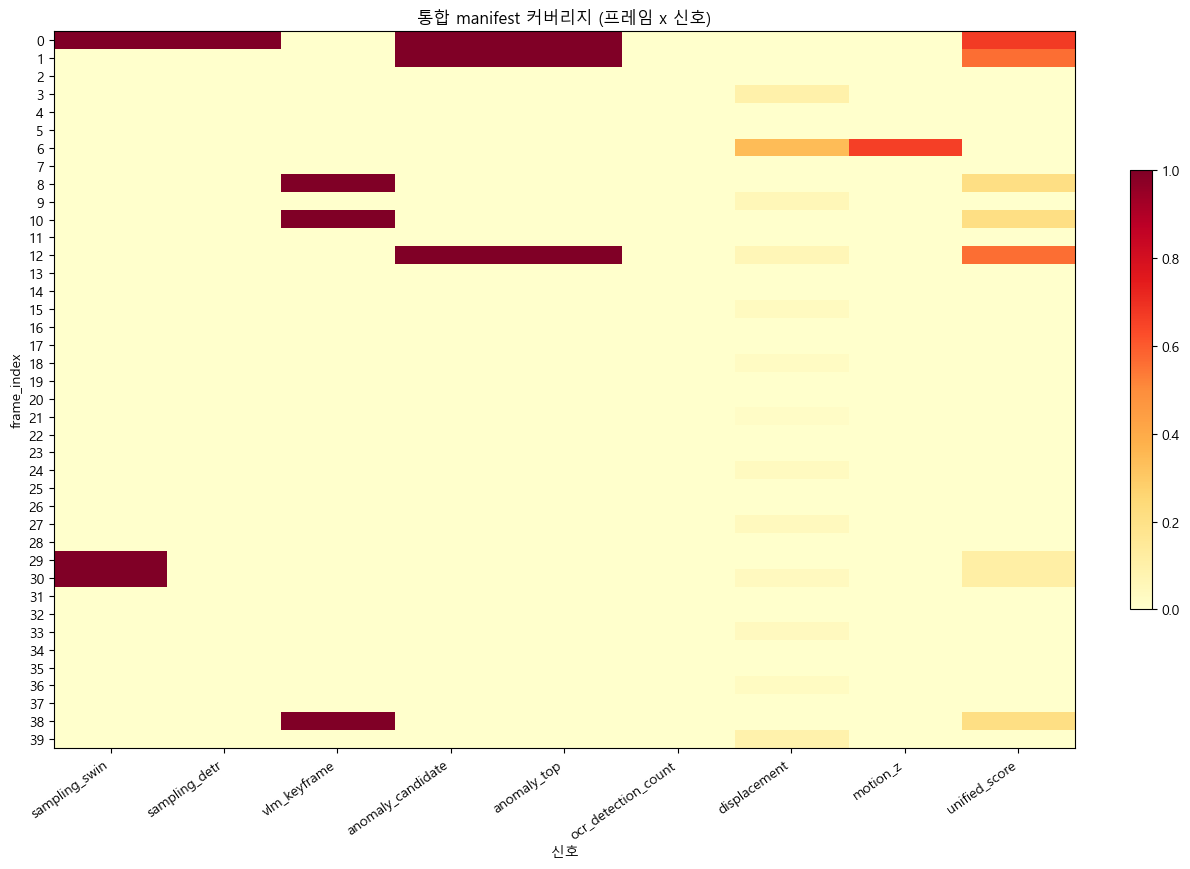

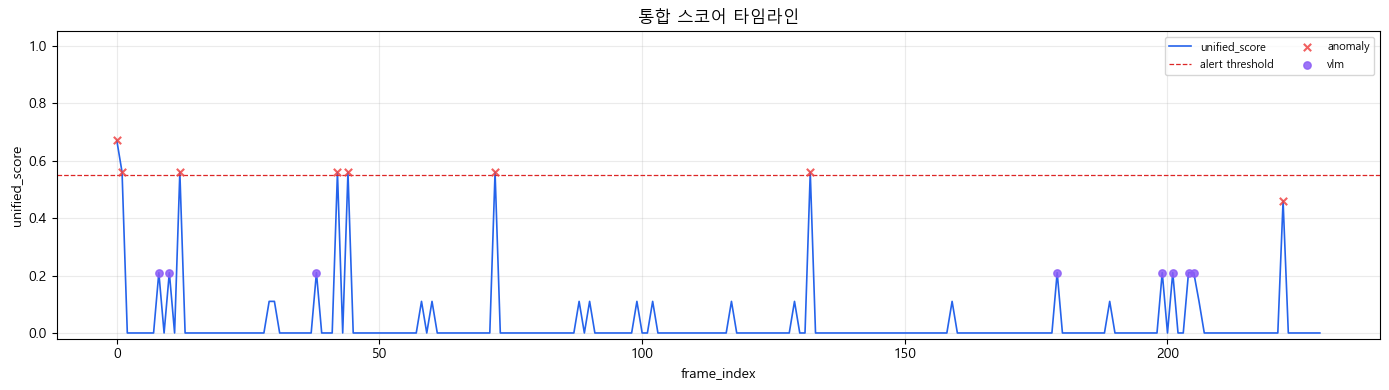

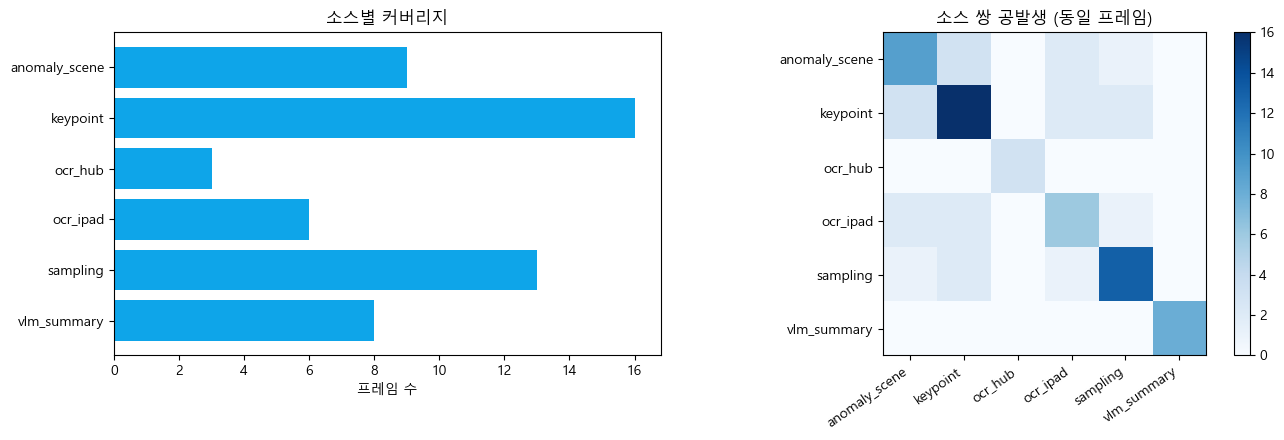

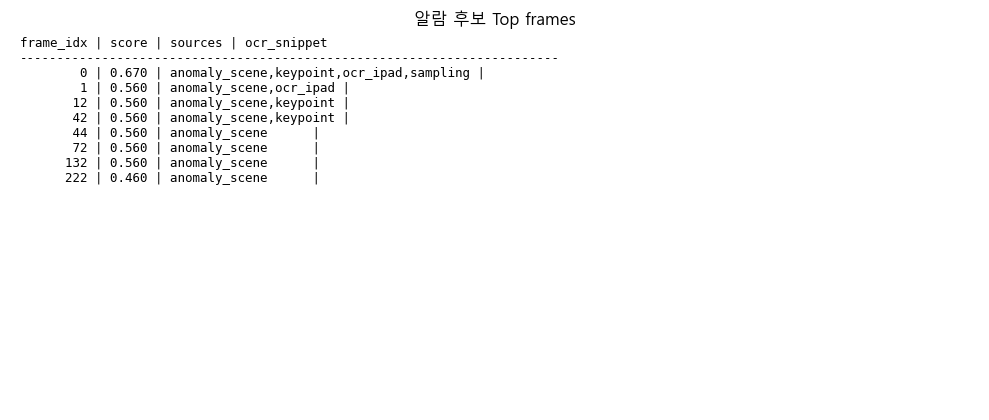

통합 manifest 저장: output_unified\unified_manifest.json
CSV export: output_unified\unified_frames.csv
  frames=233 | alerts=8


In [7]:
# ── Part 4: export · 시각화 ──

def export_frames_csv(records: list[dict], path: Path) -> Path:
    """다운스트림 BI/엑셀용 플랫 CSV."""
    import csv
    # 중첩 signals dict를 한 행에 펼친 컬럼 정의
    fieldnames = [
        "frame_index", "frame_key", "time_sec", "unified_score",
        "signal_agreement", "source_count", "sources",
        "anomaly_candidate", "vlm_keyframe", "motion_z",
        "ocr_detection_count", "ocr_snippet",
    ]
    with path.open("w", newline="", encoding="utf-8-sig") as f:
        # utf-8-sig: Excel에서 한글 깨짐 방지 (BOM 포함)
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for r in records:
            sig = r["signals"]
            writer.writerow({
                "frame_index": r.get("frame_index"),
                "frame_key": r.get("frame_key"),
                "time_sec": r.get("time_sec"),
                "unified_score": sig.get("unified_score"),
                "signal_agreement": sig.get("signal_agreement"),
                "source_count": sig.get("source_count"),
                "sources": "|".join(r.get("sources", [])),
                "anomaly_candidate": sig.get("anomaly_candidate"),
                "vlm_keyframe": sig.get("vlm_keyframe"),
                "motion_z": sig.get("motion_z"),
                "ocr_detection_count": sig.get("ocr_detection_count"),
                "ocr_snippet": (sig.get("ocr_full_text") or "")[:80],
            })
    return path


def plot_unified_timeline(records: list[dict], save_path: Path) -> None:
    """프레임별 unified_score 시계열 + 주요 이벤트 마커."""
    idxs = [r["frame_index"] for r in records if r.get("frame_index") is not None]
    scores = [r["signals"]["unified_score"] for r in records if r.get("frame_index") is not None]
    if not idxs:
        return

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(idxs, scores, color="#2563eb", linewidth=1.2, label="unified_score")
    ax.axhline(ALERT_SCORE_THRESHOLD, color="#dc2626", linestyle="--", linewidth=0.9, label="alert threshold")

    # 이상·VLM·motion 급증 프레임을 scatter로 오버레이
    for label, key, color, marker in [
        ("anomaly", "anomaly_candidate", "#ef4444", "x"),
        ("vlm", "vlm_keyframe", "#8b5cf6", "o"),
        ("motion spike", "motion_z", "#f59e0b", "^"),
    ]:
        pts = []
        for r in records:
            sig = r["signals"]
            if r.get("frame_index") is None:
                continue
            if key == "motion_z":
                mz = sig.get("motion_z")
                if isinstance(mz, (int, float)) and mz >= MOTION_Z_THRESHOLD:
                    pts.append(r["frame_index"])
            elif sig.get(key):
                pts.append(r["frame_index"])
        if pts:
            ax.scatter(pts, [scores[idxs.index(p)] for p in pts if p in idxs],
                       s=28, marker=marker, color=color, alpha=0.85, label=label, zorder=3)

    ax.set_xlabel("frame_index")
    ax.set_ylabel("unified_score")
    ax.set_title("통합 스코어 타임라인")
    ax.set_ylim(-0.02, 1.05)
    ax.legend(loc="upper right", fontsize=8, ncol=2)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    fig.savefig(save_path, dpi=130, bbox_inches="tight")
    plt.show()


def plot_source_overlap(records: list[dict], save_path: Path) -> None:
    """소스별 프레임 커버리지 막대 + 소스 쌍 공발생 히트맵."""
    from itertools import combinations

    source_names = sorted({s for r in records for s in r.get("sources", [])})
    if not source_names:
        return

    counts = {s: sum(1 for r in records if s in r.get("sources", [])) for s in source_names}
    pairs = list(combinations(source_names, 2))
    # 대각선=단독 커버리지, 비대각선=두 소스가 동시에 기여한 프레임 수
    co_mat = np.zeros((len(source_names), len(source_names)), dtype=np.float32)
    for i, a in enumerate(source_names):
        co_mat[i, i] = counts[a]
        for j, b in enumerate(source_names):
            if j <= i:
                continue
            n = sum(1 for r in records if a in r.get("sources", []) and b in r.get("sources", []))
            co_mat[i, j] = co_mat[j, i] = n

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].barh(source_names, [counts[s] for s in source_names], color="#0ea5e9")
    axes[0].set_xlabel("프레임 수")
    axes[0].set_title("소스별 커버리지")
    axes[0].invert_yaxis()

    im = axes[1].imshow(co_mat, cmap="Blues")
    axes[1].set_xticks(range(len(source_names)))
    axes[1].set_yticks(range(len(source_names)))
    axes[1].set_xticklabels(source_names, rotation=35, ha="right")
    axes[1].set_yticklabels(source_names)
    axes[1].set_title("소스 쌍 공발생 (동일 프레임)")
    fig.colorbar(im, ax=axes[1], fraction=0.046)
    plt.tight_layout()
    fig.savefig(save_path, dpi=130, bbox_inches="tight")
    plt.show()


def export_unified_manifest(
    records: list[dict],
    alerts: list[dict],
    clip_meta: dict,
    coverage: dict,
) -> Path:
    """프레임 목록·알람 후보·클립 메타·커버리지를 하나의 JSON으로 저장."""
    payload = {
        "version": "1.0",
        "created_at": datetime.now(timezone.utc).isoformat(),
        "description": "03~07 파이프라인 통합 manifest",
        "coverage": coverage,
        "clip_meta": clip_meta,
        "num_frames": len(records),
        "alert_candidates": alerts,
        "frames": records,
    }
    UNIFIED_MANIFEST_PATH.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
    return UNIFIED_MANIFEST_PATH


def plot_manifest_coverage(records: list[dict], save_path: Path, max_rows: int = 40) -> None:
    # 프레임 x 신호 유무 히트맵.
    signal_cols = [
        "sampling_swin", "sampling_detr", "vlm_keyframe",
        "anomaly_candidate", "anomaly_top", "ocr_detection_count",
        "displacement", "motion_z", "unified_score",
    ]
    rows = records[:max_rows]  # 프레임 수가 많을 때 앞쪽 max_rows만 시각화
    if not rows:
        print("[Plot] 레코드 없음")
        return

    mat = np.zeros((len(rows), len(signal_cols)), dtype=np.float32)
    for i, rec in enumerate(rows):
        sig = rec["signals"]
        for j, col in enumerate(signal_cols):
            val = sig.get(col, 0)
            if isinstance(val, bool):
                mat[i, j] = 1.0 if val else 0.0
            elif col == "ocr_detection_count":
                mat[i, j] = 1.0 if (val or 0) > 0 else 0.0
            elif col == "unified_score":
                mat[i, j] = float(val or 0)
            else:
                # displacement·motion_z 등 연속값은 0~3 구간을 0~1로 스케일
                mat[i, j] = 0.0 if val is None else min(float(val) / 3.0, 1.0)

    fig, ax = plt.subplots(figsize=(12, max(4, len(rows) * 0.22)))
    im = ax.imshow(mat, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)
    ax.set_xticks(range(len(signal_cols)))
    ax.set_xticklabels(signal_cols, rotation=35, ha="right")
    ylabels = [str(r.get("frame_index", "?")) for r in rows]
    ax.set_yticks(range(len(rows)))
    ax.set_yticklabels(ylabels)
    ax.set_xlabel("신호")
    ax.set_ylabel("frame_index")
    ax.set_title("통합 manifest 커버리지 (프레임 x 신호)")
    fig.colorbar(im, ax=ax, fraction=0.02)
    plt.tight_layout()
    fig.savefig(save_path, dpi=130, bbox_inches="tight")
    plt.show()


clip_meta_rec = frame_store.get("_clip_meta")
# 클립 단위 신호(VLM 요약, anomaly 장면 목록 등)를 export payload용 dict로 변환
clip_meta = {
    "signals": clip_meta_rec.signals if clip_meta_rec else {},
    "sources": sorted(set(clip_meta_rec.sources)) if clip_meta_rec else [],
}

manifest_path = export_unified_manifest(
    unified_records,
    alert_candidates,
    clip_meta,
    coverage,
)
csv_path = export_frames_csv(unified_records, OUTPUT_DIR / "unified_frames.csv")
# 시각화 일괄 생성: 커버리지 히트맵 → 타임라인 → 소스 공발생
plot_manifest_coverage(unified_records, FIG_DIR / "01_coverage_heatmap.png")
plot_unified_timeline(unified_records, FIG_DIR / "03_unified_timeline.png")
plot_source_overlap(unified_records, FIG_DIR / "04_source_overlap.png")

# 알람 후보 요약표
# matplotlib text로 monospace 표 형태 출력 후 PNG 저장
if alert_candidates:
    fig, ax = plt.subplots(figsize=(10, 0.35 * len(alert_candidates) + 1.5))
    ax.axis("off")
    lines = ["frame_idx | score | sources | ocr_snippet", "-" * 72]
    for r in alert_candidates:
        ocr = (r["signals"].get("ocr_full_text") or "")[:40].replace("\n", " ")
        lines.append(
            f"{str(r.get('frame_index')):>9} | {r['signals']['unified_score']:.3f} | "
            f"{','.join(r['sources']):<18} | {ocr}"
        )
    ax.text(0.01, 0.99, "\n".join(lines), va="top", family="monospace", fontsize=9)
    ax.set_title("알람 후보 Top frames")
    plt.tight_layout()
    fig.savefig(FIG_DIR / "02_alert_candidates.png", dpi=130, bbox_inches="tight")
    plt.show()

print(f"통합 manifest 저장: {manifest_path}")
print(f"CSV export: {csv_path}")
print(f"  frames={len(unified_records)} | alerts={len(alert_candidates)}")


## Part 5 — Manifest Query API

통합 manifest를 **조건 검색**하는 실무용 헬퍼입니다. 대시보드·리포트·후속 파이프라인에서 재사용합니다.

### 기술 설명 — Manifest Query API

**이 단계에서 하는 일**  
`unified_manifest.json`을 만든 뒤에도, 매번 JSON 전체를 눈으로 훑거나 파이썬 루프를 새로 짜기는 번거롭습니다. `ManifestQuery` 클래스는 **자주 쓰는 검색 조건**을 메서드로 묶어, 대시보드·리포트·후속 스크립트에서 바로 재사용할 수 있게 합니다.

**초보자가 알아두면 좋은 개념**

| 메서드 | 하는 일 | 예시 용도 |
|--------|---------|-----------|
| `by_score(min)` | 점수 이상 프레임만 필터 | 알람 임계값 0.55 이상 목록 |
| `by_source(name)` | 특정 파이프라인이 기여한 프레임 | keypoint만 있는 프레임 확인 |
| `by_time_range(s, e)` | 초 단위 시간 구간 필터 | 0~1초 구간 이벤트 조사 |
| `with_ocr_keyword(kw)` | OCR 텍스트에 키워드 포함 | “경고”, “ERROR” 문자열 검색 |
| `top_alerts(k)` | 상위 k개 고득점 프레임 | 빠른 Top-N 리포트 |
| `summary()` | 전체 통계 한 줄 요약 | 평균·최대 score, 소스 목록 |

**왜 API 형태로 만드나?**  
- JSON 파일은 **저장 형식**이고, Query는 **읽기 인터페이스**입니다.  
- SQL에서 `SELECT ... WHERE ...`를 쓰는 것과 비슷하게, manifest에도 조건 검색 계층이 있으면 유지보수가 쉬워집니다.  
- 나중에 웹 대시보드나 REST API로 옮길 때도 같은 메서드 이름·로직을 그대로 활용할 수 있습니다.

**실행 결과 예시**  
- `summary()` → 프레임 수, 평균/최대 score, threshold 이상 프레임 수  
- `by_time_range(0.0, 1.0)` → 클립 시작 1초 구간에 해당하는 프레임 목록

In [8]:
# ── Part 5: ManifestQuery API ──

class ManifestQuery:
    """unified_records + clip_meta 기반 조건 검색.
    대시보드 필터·리포트 생성·후속 파이프라인 입력으로 재사용."""

    def __init__(self, records: list[dict], clip_meta: dict | None = None):
        self.records = records
        self.clip_meta = clip_meta or {}

    def by_score(self, min_score: float = 0.5) -> list[dict]:
        """unified_score가 min_score 이상인 프레임만 반환."""
        return [r for r in self.records if r["signals"].get("unified_score", 0) >= min_score]

    def by_source(self, source_name: str) -> list[dict]:
        """특정 manifest 소스(sampling, keypoint 등)가 기여한 프레임만 반환."""
        return [r for r in self.records if source_name in r.get("sources", [])]

    def by_time_range(self, start_sec: float, end_sec: float) -> list[dict]:
        """time_sec 기준 구간 [start_sec, end_sec] 내 프레임 필터."""
        return [
            r for r in self.records
            if r.get("time_sec") is not None and start_sec <= float(r["time_sec"]) <= end_sec
        ]

    def with_ocr_keyword(self, keyword: str) -> list[dict]:
        """OCR full_text에 keyword(대소문자 무시)가 포함된 프레임 검색."""
        kw = keyword.strip().lower()
        return [
            r for r in self.records
            if kw in (r["signals"].get("ocr_full_text") or "").lower()
        ]

    def top_alerts(self, k: int = ALERT_TOP_K) -> list[dict]:
        """unified_score 상위 k개 프레임 (알람 후보 빠른 조회)."""
        return sorted(
            self.records,
            key=lambda r: r["signals"].get("unified_score", 0),
            reverse=True,
        )[:k]

    def summary(self) -> dict:
        """전체 클립에 대한 요약 통계 (프레임 수, 평균/최대 score, 고득점 프레임 수)."""
        scores = [r["signals"].get("unified_score", 0) for r in self.records]
        return {
            "num_frames": len(self.records),
            "mean_score": round(float(np.mean(scores)), 4) if scores else 0.0,
            "max_score": round(float(np.max(scores)), 4) if scores else 0.0,
            "high_score_frames": sum(1 for s in scores if s >= ALERT_SCORE_THRESHOLD),
            "sources_in_clip": sorted({s for r in self.records for s in r.get("sources", [])}),
        }


mq = ManifestQuery(unified_records, clip_meta)
print("Query summary:", json.dumps(mq.summary(), ensure_ascii=False, indent=2))

# 데모: 0~1초 구간 프레임 수 vs threshold 이상 프레임 수
demo = mq.by_time_range(0.0, 1.0)
print(f"\n0~1초 구간 프레임: {len(demo)} | score>=0.55: {len(mq.by_score(0.55))}")
if demo:
    d0 = max(demo, key=lambda r: r["signals"]["unified_score"])
    print(f"  구간 내 최고 score: idx={d0.get('frame_index')} score={d0['signals']['unified_score']:.3f}")

Query summary: {
  "num_frames": 233,
  "mean_score": 0.0334,
  "max_score": 0.67,
  "high_score_frames": 7,
  "sources_in_clip": [
    "anomaly_scene",
    "keypoint",
    "ocr_hub",
    "ocr_ipad",
    "sampling",
    "vlm_summary"
  ]
}

0~1초 구간 프레임: 31 | score>=0.55: 7
  구간 내 최고 score: idx=0 score=0.670


## Part 6 — 다중 신호 상관 · 공발생 분석

`motion_z`와 이상 탐지 플래그의 **시간적 정렬**을 보고, 파이프라인 간 **공발생 매트릭스**를 산출합니다.

### 기술 설명 — 다중 신호 상관 · 공발생 분석

**이 단계에서 하는 일**  
프레임마다 점수를 매기는 것만으로는 “여러 AI 모듈이 같은 구간을 가리키는지” 알기 어렵습니다. 이 섹션은 **신호 간 상관관계**와 **소스 쌍 공발생**을 계산해, 파이프라인 결과가 서로 얼마나 일치하는지 분석합니다.

**초보자가 알아두면 좋은 개념**

| 용어 | 쉬운 설명 |
|------|-----------|
| **이진 신호** | 프레임마다 “해당 조건 충족(1) / 아님(0)”으로 단순화한 값 |
| **Pearson 상관계수** | 두 신호가 같은 프레임에서 함께 켜지는 경향 (-1~1, 1에 가까울수록 동조) |
| **공발생(co-occurrence)** | 같은 프레임에 두 manifest 소스가 **동시에** 기록된 횟수 |
| **signal_agreement** | 5개 독립 파이프라인 중 몇 개가 “주목 프레임”으로 투표했는지 (0~1) |

**해석 가이드**  
- `anomaly_candidate ~ motion_z` 상관이 높으면 → **이상 탐지와 움직임 급증이 같은 구간**에서 발생  
- `vlm_keyframe`과 다른 신호 상관이 낮으면 → VLM이 고른 키프레임이 **다른 모듈 관심 구간과 다를 수 있음**  
- `high_agreement_frames`가 많으면 → 여러 파이프라인이 **동시에 주목한 신뢰도 높은 구간**이 많다는 뜻

**출력 파일**  
- `output_unified/signal_cooccurrence.json` — 상관·공발생·평균 agreement 수치  
- `figures/05_agreement_histogram.png` — agreement 분포 히스토그램

> 상관계수는 **데모용 이진화** 기준입니다. 실무에서는 연속값(점수·z-score) 그대로 분석하는 것이 더 정밀합니다.

신호 상관: {'anomaly_candidate~vlm_keyframe': -0.0356, 'anomaly_candidate~motion_z': 0.0, 'vlm_keyframe~motion_z': 0.0}
평균 agreement: 0.028 | high(>=0.6): 0
공발생 리포트: output_unified\signal_cooccurrence.json


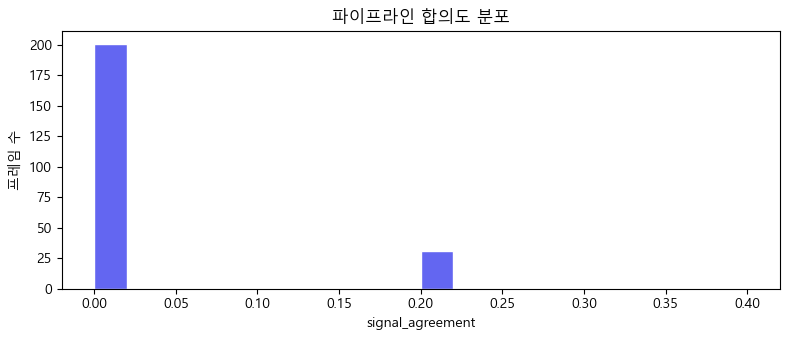

In [9]:
# ── Part 6: 신호 상관 · 공발생 리포트 ──

def compute_signal_correlation(records: list[dict]) -> dict[str, float]:
    """이진 신호 벡터 간 Pearson 상관 (데모용).
    각 신호를 프레임별 0/1로 이진화한 뒤 쌍별 상관계수 계산."""

    def bin_vec(key: str) -> np.ndarray:
        """신호 키를 프레임 순 이진 벡터로 변환."""
        vals = []
        for r in records:
            sig = r["signals"]
            if key == "motion_z":
                mz = sig.get("motion_z")
                vals.append(1.0 if isinstance(mz, (int, float)) and mz >= MOTION_Z_THRESHOLD else 0.0)
            else:
                vals.append(1.0 if sig.get(key) else 0.0)
        return np.array(vals, dtype=np.float32)

    keys = ["anomaly_candidate", "vlm_keyframe", "motion_z"]
    vecs = {k: bin_vec(k) for k in keys}
    out: dict[str, float] = {}
    for i, a in enumerate(keys):
        for b in keys[i + 1:]:
            va, vb = vecs[a], vecs[b]
            # 분산이 0이면 상관 정의 불가 → 0으로 처리
            if va.std() < 1e-6 or vb.std() < 1e-6:
                out[f"{a}~{b}"] = 0.0
            else:
                out[f"{a}~{b}"] = round(float(np.corrcoef(va, vb)[0, 1]), 4)
    return out


def build_cooccurrence_report(records: list[dict]) -> dict:
    """소스 쌍 공발생 횟수·agreement 통계·신호 상관을 하나의 리포트 dict로 묶음."""
    from itertools import combinations
    sources = sorted({s for r in records for s in r.get("sources", [])})
    pair_counts = {}
    for a, b in combinations(sources, 2):
        pair_counts[f"{a}+{b}"] = sum(
            1 for r in records if a in r.get("sources", []) and b in r.get("sources", [])
        )
    agreement = [r["signals"].get("signal_agreement", 0) for r in records]
    return {
        "pair_cooccurrence": pair_counts,
        "mean_agreement": round(float(np.mean(agreement)), 4) if agreement else 0.0,
        "high_agreement_frames": sum(1 for a in agreement if a >= 0.6),
        "signal_correlation": compute_signal_correlation(records),
    }


co_report = build_cooccurrence_report(unified_records)
CO_REPORT_PATH = OUTPUT_DIR / "signal_cooccurrence.json"
CO_REPORT_PATH.write_text(json.dumps(co_report, ensure_ascii=False, indent=2), encoding="utf-8")

print("신호 상관:", co_report["signal_correlation"])
print(f"평균 agreement: {co_report['mean_agreement']:.3f} | high(>=0.6): {co_report['high_agreement_frames']}")
print(f"공발생 리포트: {CO_REPORT_PATH}")

# agreement 분포 히스토그램
# 파이프라인 합의도가 높은 프레임이 얼마나 있는지 분포로 확인
ag_vals = [r["signals"].get("signal_agreement", 0) for r in unified_records]
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(ag_vals, bins=20, color="#6366f1", edgecolor="white")
ax.set_xlabel("signal_agreement")
ax.set_ylabel("프레임 수")
ax.set_title("파이프라인 합의도 분포")
plt.tight_layout()
fig.savefig(FIG_DIR / "05_agreement_histogram.png", dpi=130, bbox_inches="tight")
plt.show()

## Part 7 — 알람 후보 썸네일 모자이크

알람 후보 프레임을 **OpenCV**로 읽어 그리드 모자이크로 시각 검증합니다.

### 기술 설명 — 알람 후보 썸네일 모자이크

**이 단계에서 하는 일**  
숫자·표만으로는 알람 후보가 실제로 어떤 화면인지 직관적으로 파악하기 어렵습니다. 이 섹션은 `alert_candidates`에 담긴 `image_path`로 원본 프레임을 읽어, 작은 썸네일 그리드(모자이크)로 한눈에 보여 줍니다.

**초보자가 알아두면 좋은 개념**

| 용어 | 쉬운 설명 |
|------|-----------|
| **썸네일(thumbnail)** | 원본보다 작게 줄인 미리보기 이미지 |
| **모자이크(mosaic)** | 여러 썸네일을 격자처럼 이어 붙인 한 장의 그림 |
| **BGR / RGB** | OpenCV는 BGR 순서, matplotlib은 RGB 순서로 색을 읽음 → 표시 전 변환 필요 |
| **imdecode** | Windows에서 한글 경로 이미지를 안전하게 읽기 위한 방식 (`imread` 대신 사용) |

**왜 시각 검증이 필요한가?**  
- 이상 탐지·OCR·모션 신호가 겹쳐 점수가 높아도, 실제로는 **정상 동작**일 수 있습니다.  
- 반대로 점수는 낮지만 **육안으로 명확한 이상**이 있을 수도 있습니다.  
- 모자이크는 엔지니어가 최종 판단하기 전 **1차 육안 점검**용입니다.

**출력 파일**  
- `figures/06_alert_mosaic.jpg` — 각 타일 상단에 `#프레임번호 s=점수` 라벨이 붙습니다.

> 이미지 경로가 없거나 파일을 읽지 못하면 `[WARN] 썸네일 생성 실패`가 출력됩니다. IPAD 프레임 폴더가 올바른지 확인하세요.

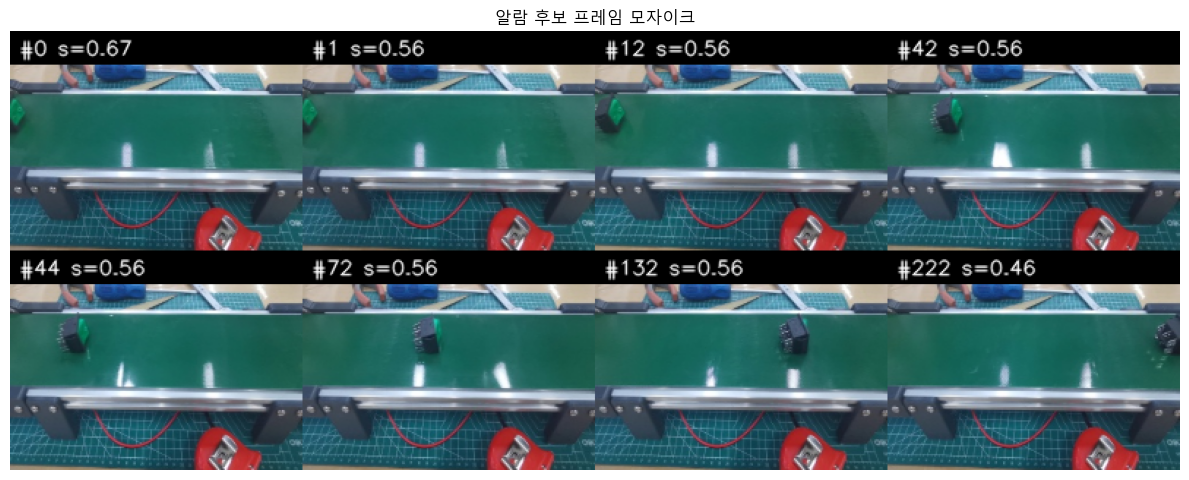

모자이크 저장: output_unified\figures\06_alert_mosaic.jpg


In [10]:
# ── Part 7: 알람 후보 썸네일 모자이크 ──

import cv2


def read_frame_bgr(path: str | Path) -> np.ndarray | None:
    """디스크에서 BGR 이미지 로드. 실패 시 None."""
    p = Path(path)
    if not p.is_file():
        return None
    # Windows 한글 경로: imread 대신 imdecode 사용
    buf = np.fromfile(str(p), dtype=np.uint8)
    if buf.size == 0:
        return None
    return cv2.imdecode(buf, cv2.IMREAD_COLOR)


def build_alert_mosaic(
    alerts: list[dict],
    thumb_size: tuple[int, int] = (200, 150),
    cols: int = 4,
) -> np.ndarray | None:
    """알람 후보 프레임을 리사이즈·라벨링 후 cols열 그리드로 합성."""
    tiles: list[np.ndarray] = []
    for r in alerts:
        img = read_frame_bgr(r.get("image_path") or "")
        if img is None:
            continue
        thumb = cv2.resize(img, thumb_size)
        idx = r.get("frame_index", "?")
        score = r["signals"].get("unified_score", 0)
        label = f"#{idx} s={score:.2f}"
        # 상단 검은 바에 frame_index·score 텍스트 오버레이
        cv2.rectangle(thumb, (0, 0), (thumb_size[0], 22), (0, 0, 0), -1)
        cv2.putText(thumb, label, (6, 16), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)
        tiles.append(thumb)

    if not tiles:
        return None

    rows = int(np.ceil(len(tiles) / cols))
    blank = np.zeros((thumb_size[1], thumb_size[0], 3), dtype=np.uint8)
    # 마지막 행이 비면 검은 타일로 패딩해 직사각형 그리드 유지
    while len(tiles) < rows * cols:
        tiles.append(blank.copy())

    row_imgs = []
    for r in range(rows):
        row_imgs.append(np.hstack(tiles[r * cols:(r + 1) * cols]))
    return np.vstack(row_imgs)


mosaic_bgr = build_alert_mosaic(alert_candidates)
if mosaic_bgr is not None:
    mosaic_rgb = cv2.cvtColor(mosaic_bgr, cv2.COLOR_BGR2RGB)  # matplotlib 표시용 RGB 변환
    mosaic_path = FIG_DIR / "06_alert_mosaic.jpg"
    cv2.imwrite(str(mosaic_path), mosaic_bgr)
    fig, ax = plt.subplots(figsize=(12, 3 * max(1, int(np.ceil(len(alert_candidates) / 4)))))
    ax.imshow(mosaic_rgb)
    ax.axis("off")
    ax.set_title("알람 후보 프레임 모자이크")
    plt.tight_layout()
    plt.show()
    print(f"모자이크 저장: {mosaic_path}")
else:
    print("[WARN] 썸네일 생성 실패 — image_path 확인")

---

### 실습 요약

- **Part 1** — 03~07 manifest 존재 확인 · IPAD testing 타임라인 · 스키마 경고
- **Part 2** — 소스별 signal 추출 · frame_key 정규화
- **Part 3** — `merge_frame_records` · unified_score · signal_agreement · 알람 후보
- **Part 4** — `unified_manifest.json` · CSV · 커버리지/타임라인/공발생 차트
- **Part 5** — `ManifestQuery` 조건 검색 API
- **Part 6** — 신호 상관 · 공발생 리포트 · agreement 히스토그램
- **Part 7** — 알람 후보 썸네일 모자이크

## 생성 파일

| 파일 | 설명 |
|------|------|
| `output_unified/unified_manifest.json` | 프레임별 통합 신호 + 알람 후보 |
| `output_unified/unified_frames.csv` | BI/엑셀용 플랫 export |
| `output_unified/manifest_coverage.json` | 로드된/누락 manifest + 스키마 경고 |
| `output_unified/signal_cooccurrence.json` | 소스 공발생 · 신호 상관 |
| `figures/01_coverage_heatmap.png` | 프레임 x 신호 히트맵 |
| `figures/02_alert_candidates.png` | 알람 후보 요약표 |
| `figures/03_unified_timeline.png` | unified_score 시계열 |
| `figures/04_source_overlap.png` | 소스 커버리지 · 공발생 |
| `figures/05_agreement_histogram.png` | 파이프라인 합의도 분포 |
| `figures/06_alert_mosaic.jpg` | 알람 후보 썸네일 그리드 |

## FAQ

**Q. manifest가 대부분 MISSING이에요.**  
A. 해당 번호 노트북(03~07)을 먼저 실행하세요. IPAD만 있어도 keypoint manifest는 생성 가능합니다.

**Q. OCR이 AI Hub만 있고 IPAD OCR이 없어요.**  
A. `ocr_hub`만 병합됩니다. 06 Part 4에서 IPAD 프레임 OCR을 실행하면 `ocr_ipad`가 추가됩니다.

**Q. unified_score는 어떻게 쓰나요?**  
A. `SCORE_WEIGHTS`와 `ALERT_SCORE_THRESHOLD`로 조정합니다. `signal_agreement`가 높은 프레임은 다중 파이프라인이 동시에 주목한 구간입니다.

**Q. OCR이 ipad·hub 둘 다 있으면?**  
A. `merge_frame_records`가 `ocr_ipad`를 우선합니다.
